<a href="https://colab.research.google.com/github/Nikerlas/ImageProcess/blob/main/MENGUKUR_KEMIRIPAN_CITRA_DAN_PENERAPANNYA_DALAM_PENGENALAN_POLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#P1. Menghitung Jarak berbasis Pixel

In [ ]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

In [ ]:
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]
patch3 = patch1 + 0.1
patch3 = np.clip(patch3, 0, 1)

In [ ]:
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

In [ ]:
dist_12_12 = distance.euclidean(vec1, vec2)
dist_12_13 = distance.euclidean(vec1, vec3)

In [ ]:
dist_11_12 = distance.cityblock(vec1, vec2)
dist_11_13 = distance.cityblock(vec1, vec3)

In [ ]:
print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_12_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_12_13:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_11_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_11_13:.4f}")

Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


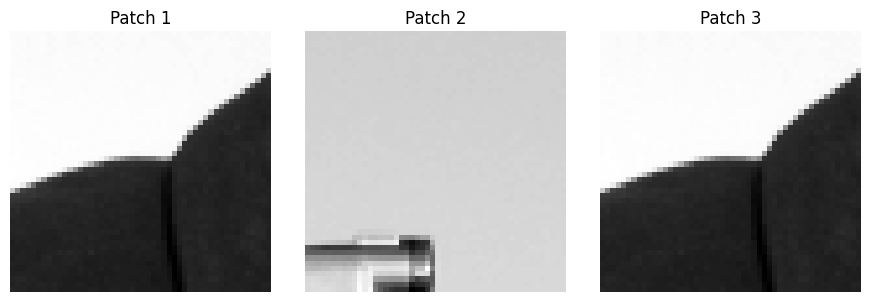

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')
axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')
axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3')
axes[2].axis('off')
plt.tight_layout()
plt.show()

#P2. Menghitung Cosine Similarity antara Histogram Warna

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte, io, color
from scipy.spatial import distance

In [ ]:
def calculate_rgb_histogram(image, bins=16):
  img_uint8 = img_as_ubyte(image)
  hist_r, _ = np.histogram(img_uint8[:, :, 0].ravel(), bins=bins, range=(0, 256))
  hist_g, _ = np.histogram(img_uint8[:, :, 1].ravel(), bins=bins, range=(0, 256))
  hist_b, _ = np.histogram(img_uint8[:, :, 2].ravel(), bins=bins, range=(0, 256))
  hist_combined = np.concatenate((hist_r, hist_g, hist_b))
  hist_combined = hist_combined.astype(float) / np.sum(hist_combined)
  return hist_combined

In [ ]:
try:
  image1 = data.astronaut()
  image2 = data.coffee()
  image3 = data.astronaut()
  image4 = image1[::2, ::2, :]
except Exception as e:
  print(f"Gagal memuat data skimage: {e}. Membuat citra dummy")
  image1 = np.random.rand(100, 100, 3)
  image2 = np.random.rand(100, 100, 3) * 0.5
  image3 = image1.copy()
  image4 = image1[::2, ::2, :]

In [ ]:
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

In [ ]:
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

Cosine similarity antara image 1 (Astronaut) dan Image 2 (Coffee): 0.8156
Cosine similarity antara image 1 (Astronaut) dan Image 3 (Astronaut): 1.0000
Cosine similarity antara image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): 1.0000


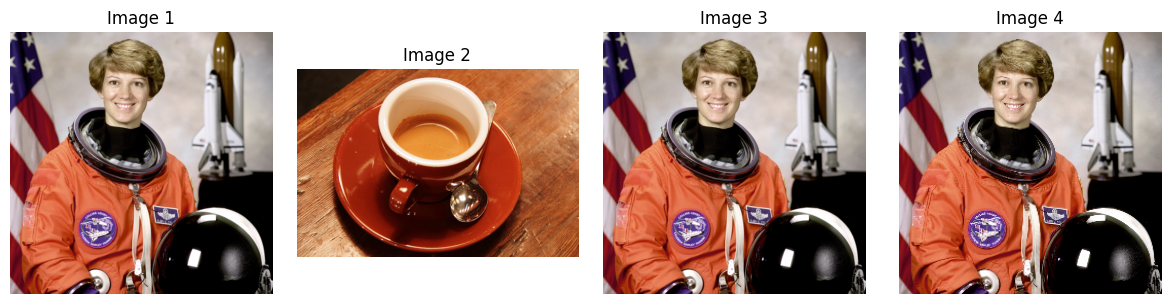

In [ ]:
print(f"Cosine similarity antara image 1 (Astronaut) dan Image 2 (Coffee): {sim_12:.4f}")
print(f"Cosine similarity antara image 1 (Astronaut) dan Image 3 (Astronaut): {sim_13:.4f}")
print(f"Cosine similarity antara image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): {sim_14:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(image1)
axes[0].set_title('Image 1')
axes[0].axis('off')
axes[1].imshow(image2)
axes[1].set_title('Image 2')
axes[1].axis('off')
axes[2].imshow(image3)
axes[2].set_title('Image 3')
axes[2].axis('off')
axes[3].imshow(image4)
axes[3].set_title('Image 4')
axes[3].axis('off')
plt.tight_layout()
plt.show()

#P3. Menghitung Structural Similarity Index (SSIM)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from skimage.util import random_noise

In [ ]:
image_ref = img_as_float(data.camera())

In [ ]:
image_same = image_ref.copy()
image_noise = random_noise(image_ref, mode='gaussian', var=0.01)
image_contrast = np.clip(image_ref * 0.8, 0, 1)
from skimage.filters import gaussian
image_blur = gaussian(image_ref, sigma=1, channel_axis=None)

In [ ]:
data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noise, diff_noisy = ssim(image_ref, image_noise, data_range=data_range, full=True)
ssim_contrast,diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blur, diff_blur = ssim(image_ref, image_blur, data_range=data_range, full=True)

SSIM (Ref vs Same): 1.0000
SSIM (Ref vs Noise): 0.2957
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blur): 0.8691


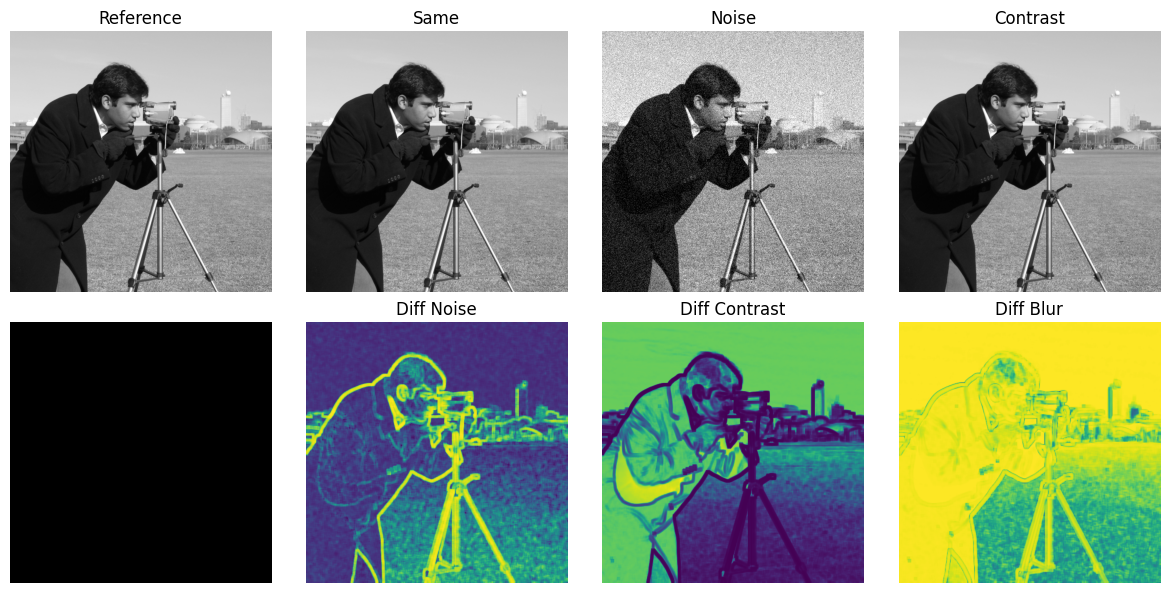

In [ ]:
print(f"SSIM (Ref vs Same): {ssim_same:.4f}")
print(f"SSIM (Ref vs Noise): {ssim_noise:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blur): {ssim_blur:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()
ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title('Reference')
ax[0].axis('off')
ax[1].imshow(image_same, cmap='gray')
ax[1].set_title('Same')
ax[1].axis('off')
ax[2].imshow(image_noise, cmap='gray')
ax[2].set_title('Noise')
ax[2].axis('off')
ax[3].imshow(image_contrast, cmap='gray')
ax[3].set_title('Contrast')
ax[3].axis('off')
ax[4].imshow(np.zeros_like(image_ref), cmap='gray')
ax[4].set_title('')
ax[4].axis('off')
ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title('Diff Noise')
ax[5].axis('off')
ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('Diff Contrast')
ax[6].axis('off')
ax[7].imshow(diff_blur, cmap='viridis')
ax[7].set_title('Diff Blur')
ax[7].axis('off')
plt.tight_layout()
plt.show()

#P4 Penerapan Templlate Matching

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

In [ ]:
image = data.coins()
template = image[15:80, 190:260]

In [ ]:
result = match_template(image, template)

In [ ]:
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]

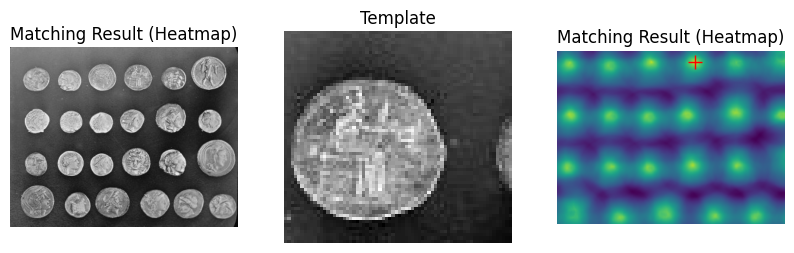

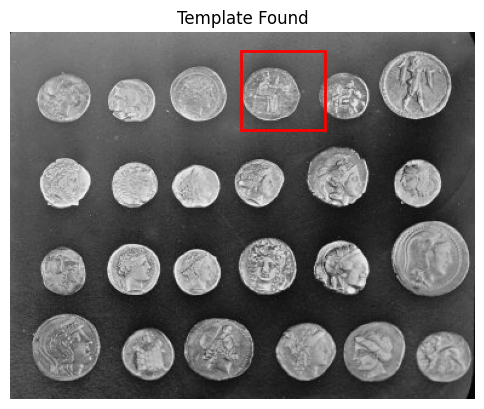

Template ditemukan di koordinat (x,y): (np.int64(190), np.int64(15))


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Matching Result (Heatmap)')
ax[0].set_axis_off()
ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].set_axis_off()
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].set_axis_off()
ax[2].plot(x, y, 'r+', markersize=10)

fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.set_axis_off()
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)
plt.show()

print(f"Template ditemukan di koordinat (x,y): {(x), (y)}")

#P5. Simulasi Content-Based Image Retrieval Sederhana

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io, color, transform, img_as_float
from scipy.spatial import distance

In [ ]:
def calculate_rgb_histogram(image, bins=16):
    if image.dtype == float:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:, :, 2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)
    return hist_combined

In [ ]:
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.


In [ ]:
distances = []
for i, hist in enumerate(database_hists):
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

In [ ]:
sorted_indices = np.argsort(distances)


Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


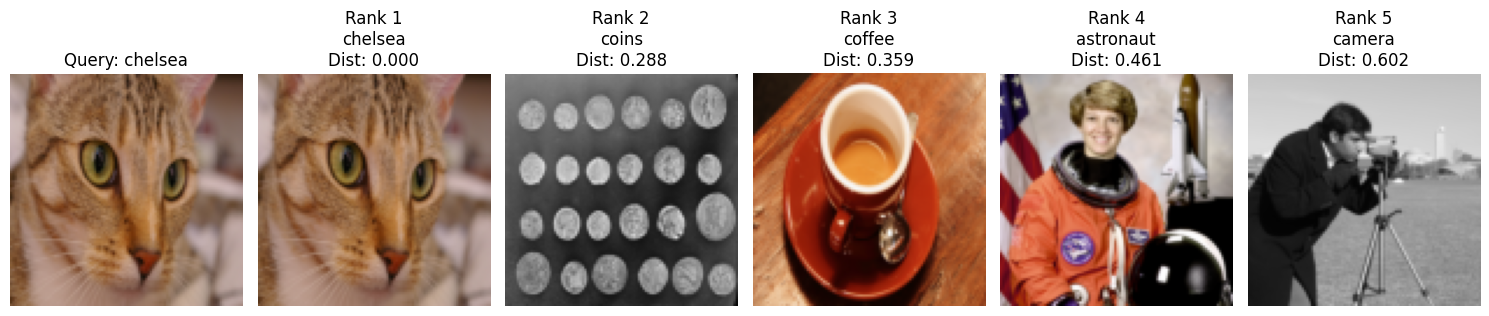

In [ ]:
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for i, idx in enumerate(sorted_indices):
    img_rank = i + 1
    ax = axes[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {img_rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

for j in range(num_results_to_show + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (berdasarkan rata-rata warna, Euclidean Distance):
Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 0.050)
Rank 3: coffee (Distance: 0.176)
Rank 4: camera (Distance: 0.194)
Rank 5: coins (Distance: 0.211)


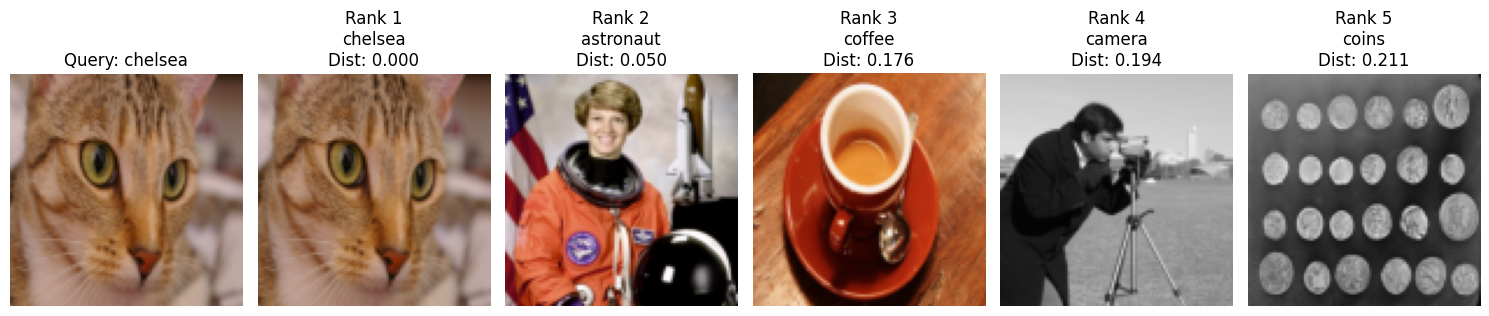

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float
from scipy.spatial import distance

def calculate_rgb_mean(image):
    if image.dtype != float:
        image = img_as_float(image)
    mean_r = np.mean(image[:, :, 0])
    mean_g = np.mean(image[:, :, 1])
    mean_b = np.mean(image[:, :, 2])
    return np.array([mean_r, mean_g, mean_b])

image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_features = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_features.append(calculate_rgb_mean(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_feature = database_features[query_index]

distances = []
for i, feature in enumerate(database_features):
    dist = distance.euclidean(query_feature, feature)
    distances.append(dist)

sorted_indices = np.argsort(distances)

num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

print("\nHasil Retrieval (berdasarkan rata-rata warna, Euclidean Distance):")
for i, idx in enumerate(sorted_indices):
    img_rank = i + 1
    ax = axes[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {img_rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

for j in range(num_results_to_show + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
